In [ ]:
# Import libraries
import random
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
# Setting a seed for the model
def set_seed(seed=42):
  # Set Python's random built-in seed
  random.seed(seed)
  # Set Python environment seed for hash stability
  os.environ['PYTHONHASHSEED'] = str(seed)
  # Set NumPy seed for data shuffling and preprocessing
  np.random.seed(seed)
  # Set TensorFlow seed for neural network weights and dropout
  tf.random.set_seed(seed)
  # Force TensorFlow to use deterministic operations
  os.environ['TF_DETERMINISTIC_OPS'] = '1'
  os.environ['TF_CUDNN_DETERMINISTIC'] = '1'

  print(f"Random seed set to: {seed}")

# Execute function
set_seed(42)

Random seed set to: 42


In [ ]:
# Import dataset
try:
  df = pd.read_csv('vvix_unscaled.csv')
  print("Dataset loaded successfully.")
  print("First five rows of the dataset:")
  print(df.head())
  print("\nDataset info:")
  df.info()
except FileNotFoundError:
  print("Dataset not found. Please make sure the file is in the correct directory.")
  exit()

Dataset loaded successfully.
First five rows of the dataset:
         Date  VVIX_Close  VVIX_Close_Lag_1  VVIX_Close_Lag_5  \
0  2007-02-02   72.440002         73.500000         81.360001   
1  2007-02-05   70.290001         72.440002         81.680000   
2  2007-02-06   68.550003         70.290001         78.900002   
3  2007-02-07   70.320000         68.550003         77.279999   
4  2007-02-08   73.180000         70.320000         73.500000   

   VVIX_Close_Lag_10  VVIX_Close_Lag_21  VVIX_Close_Pct_Change  \
0          82.489998          87.629997              -0.014422   
1          84.430000          88.190002              -0.029680   
2          81.480003          90.169998              -0.024755   
3          77.510002          92.040001               0.025821   
4          80.449997          92.760002               0.040671   

   VVIX_Close_Log_Return  VVIX_Close_Rolling_Mean_5  \
0              -0.014527                  76.760001   
1              -0.030129                 

# Data Preprocessing

In [ ]:
# Convert 'Date' into a datetime and set as index.
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Select the most important features
features = ['VVIX_Close', 'VVIX_Close_Pct_Change', 'VVIX_Close_Log_Return', 'VIX_Close', 'SPX_Close']
target = 'VVIX_Close'
target_idx = features.index(target)

data = df[features].values

# Normalize the data
scaler = MinMaxScaler(feature_range=(0,1))
data_scaled = scaler.fit_transform(data)

In [ ]:
SEQ_LENGTH = 30 # 30 days of historical data
X, y = [], []

for i in range(SEQ_LENGTH, len(data_scaled)):
  X.append(data_scaled[i-SEQ_LENGTH:i, :]) # Take all the features for 30 days
  y.append(data_scaled[i, target_idx]) # Predict tomorrow's VVIX

X, y = np.array(X), np.array(y)

In [ ]:
# Splitting data into training and test sets
split = int(0.8 * len(X))
X_train, X_test, y_train, y_test = X[:split], X[split:], y[:split], y[split:]

# Building LSTM model

In [ ]:
model = Sequential([
    tf.keras.layers.RNN(tf.keras.layers.LSTMCell(50), return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.2),
    tf.keras.layers.RNN(tf.keras.layers.LSTMCell(50), return_sequences=False),
    Dropout(0.2),
    Dense(units=25),
    Dense(units=1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rnn (RNN)                       │ (None, 30, 50)         │        11,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 50)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_1 (RNN)                     │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 25)             │         1,275 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            26 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,701 (127.74 KB)

 Trainable params: 32,701 (127.74 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 33ms/step - loss: 0.0066 - val_loss: 0.0047
Epoch 2/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0034 - val_loss: 0.0061
Epoch 3/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0028 - val_loss: 0.0029
Epoch 4/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0024 - val_loss: 0.0028
Epoch 5/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0019 - val_loss: 0.0028
Epoch 6/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 40ms/step - loss: 0.0018 - val_loss: 0.0022
Epoch 7/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 0.0017 - val_loss: 0.0016
Epoch 8/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0016 - val_loss: 0.0022
Epoch 9/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0016 - val_loss: 0.0023
Epoch 10/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 0.0016 - val_loss: 0.0019
Epoch 11/100
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - loss: 0.0015 - val_loss: 0.0018
Epoch 12/100
117/117 ━━━━━━━━━

# Model Evaluation

In [ ]:
import numpy as np
# Evaluate loss
loss = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss (Mean Squared Error): {loss:.4f}")
print(f"\n Root Mean Squared Error: {np.sqrt(loss):.4f}")

y_pred_test = model.predict(X_test)

print(f"\n Mean Absolute Error: {mean_absolute_error(y_test, y_pred_test):.4f}")
print(f"\n R-squared Score: {r2_score(y_test, y_pred_test):.4f}")

# Calculate Directional Accuracy
# Get the unscaled previous actual values from the last element of the input sequences (X_test)
actual_previous_values_scaled = X_test[:, -1, :]
actual_previous_values_unscaled = scaler.inverse_transform(actual_previous_values_scaled)

# Unscale y_test and predictions for comparison
num_features = len(features)

temp_y_test = np.zeros((len(y_test), num_features))
temp_y_test[:, target_idx] = y_test
y_test_unscaled_for_direction = scaler.inverse_transform(temp_y_test)[:, target_idx].reshape(-1, 1)

temp_y_pred = np.zeros((len(y_pred_test), num_features))
temp_y_pred[:, target_idx] = y_pred_test.flatten() # Flatten y_pred_test from (N,1) to (N,)
predictions_unscaled_for_direction = scaler.inverse_transform(temp_y_pred)[:, target_idx].reshape(-1, 1)

# Calculate actual direction of change (current actual vs. previous actual)
actual_direction = np.sign(y_test_unscaled_for_direction - actual_previous_values_unscaled[:, target_idx].reshape(-1, 1))

# Calculate predicted direction of change (current predicted vs. previous actual)
predicted_direction = np.sign(predictions_unscaled_for_direction - actual_previous_values_unscaled[:, target_idx].reshape(-1, 1))

# Compare if the actual and predicted directions are the same
correct_directions = (actual_direction == predicted_direction).sum()
total_predictions = len(actual_direction)
directional_accuracy = correct_directions / total_predictions

print(f"\nDirectional Accuracy: {directional_accuracy:.2%}")


Test Loss (Mean Squared Error): 0.0016

 Root Mean Squared Error: 0.0400
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step

 Mean Absolute Error: 0.0283

 R-squared Score: 0.8445

Directional Accuracy: 55.69%


In [ ]:
# Forecast the next day's forecast price (scaled output)
next_day_forecast_scaled = model.predict(X_test[-1, np.newaxis, :])

# Create a temporary array with the correct number of features for inverse_transform
# num_features is 5, target_idx is 0 (for VVIX_Close)
temp_next_day_forecast = np.zeros((1, num_features))
temp_next_day_forecast[0, target_idx] = next_day_forecast_scaled[0, 0] # Place the predicted VVIX_Close into the target_idx column

# Inverse transform the temporary array and extract the unscaled VVIX_Close forecast
# This variable name should match the one used in the plotting cell (hqLv8K8b9pon)
next_day_forecast = scaler.inverse_transform(temp_next_day_forecast)[0, target_idx]

# Print the forecast by extracting the scalar value from the array
print(f"Next day's Forecast: {next_day_forecast:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Next day's Forecast: 96.18


## Visualizing results

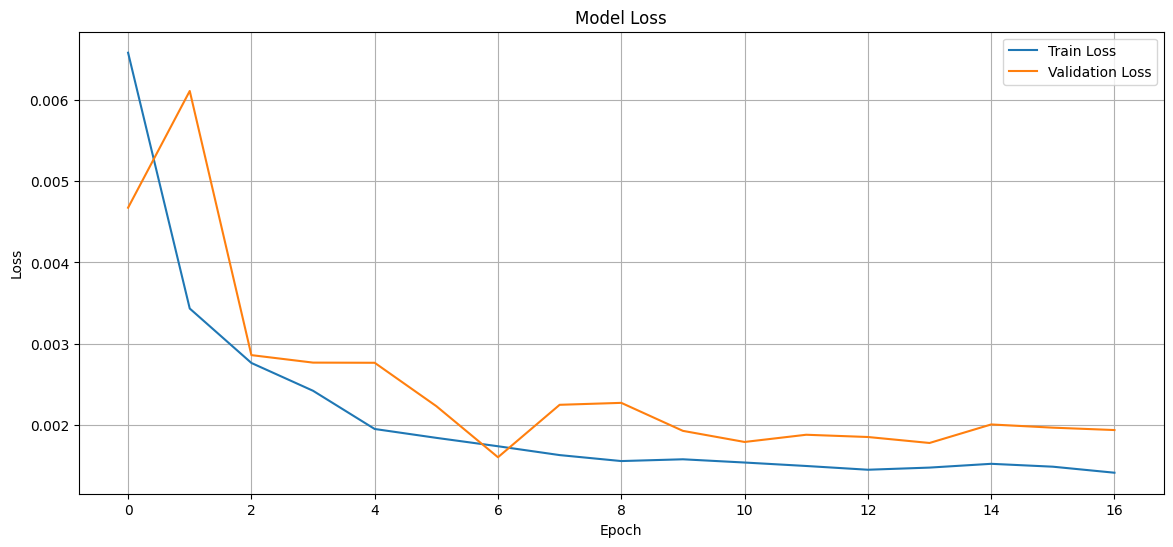

In [ ]:
# Plot training and test loss values
plt.figure(figsize=(14, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

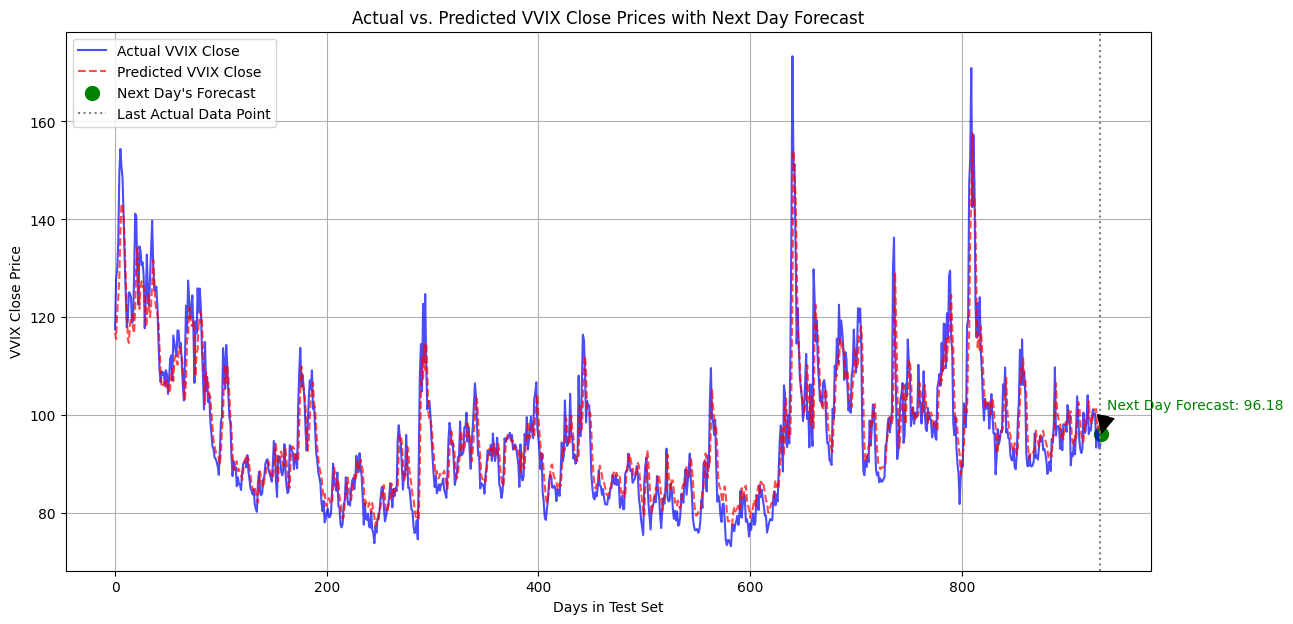

In [ ]:
plt.figure(figsize=(14, 7))

# Plot actual values
plt.plot(y_test_unscaled_for_direction, label='Actual VVIX Close', color='blue', alpha=0.7)

# Plot predicted values
plt.plot(predictions_unscaled_for_direction, label='Predicted VVIX Close', color='red', linestyle='--', alpha=0.7)

# Mark the forecast point for the next day
last_test_day_index = len(y_test_unscaled_for_direction) - 1
next_day_index = last_test_day_index + 1

# Plot the next day's forecast as a distinct point
plt.scatter(next_day_index, next_day_forecast, color='green', marker='o', s=100, label="Next Day's Forecast")
plt.axvline(x=last_test_day_index, color='gray', linestyle=':', label='Last Actual Data Point')

# Add a text annotation for the next day's forecast value
plt.annotate(f'Next Day Forecast: {next_day_forecast:.2f}',
             xy=(next_day_index, next_day_forecast),
             xytext=(next_day_index + 5, next_day_forecast + 5), # Offset text for readability
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=10, color='green')

plt.title('Actual vs. Predicted VVIX Close Prices with Next Day Forecast')
plt.ylabel('VVIX Close Price')
plt.xlabel('Days in Test Set')
plt.legend()
plt.grid(True)
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 10m

/tmp/ipykernel_8402/3338391526.py:50: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


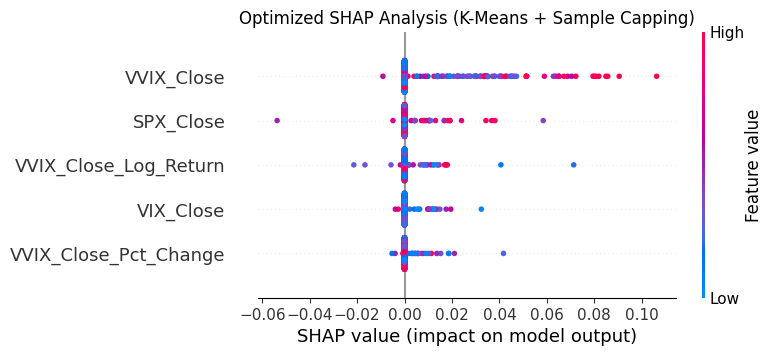

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# --- 1. The Background Summary (The "K-Means" Trick) ---
# Instead of 50 random samples, we use K-Means to find the 10 most
# representative "centroids" of your data.
# This reduces the math SHAP has to do by 80% immediately.
background_raw = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
n_samples_train, n_timesteps, n_features = background_raw.shape
background_flat = background_raw.reshape(n_samples_train, -1)

# Summarize to 10 representative points
background_summary = shap.kmeans(background_flat, 10)

# --- 2. The Wrapper (Same logic, just keeping it clean) ---
def model_predict_wrapper(x_2d):
    x_3d = x_2d.reshape(-1, n_timesteps, n_features)
    return model.predict(x_3d)

# --- 3. Initialise the Explainer ---
explainer = shap.KernelExplainer(model_predict_wrapper, background_summary)

# --- 4. Calculate SHAP Values with a Speed Limit ---
test_subset = X_test[:20] # Explain 20 samples (enough for a good plot)
test_subset_flat = test_subset.reshape(test_subset.shape[0], -1)

# 'nsamples' is the "turbo" button.
# Default is 'auto' (slow). 100-200 is usually enough for LSTMs.
shap_values = explainer.shap_values(test_subset_flat, nsamples=100)

# --- 5. Handle the List Trap & Reshape for Plotting ---
if isinstance(shap_values, list):
    shap_matrix = shap_values[0]
else:
    shap_matrix = shap_values

# Reshape back to (Samples, TimeSteps, Features) for a moment to flatten properly
# This ensures we don't accidentally mix up which feature is which
shap_matrix_3d = shap_matrix.reshape(-1, n_timesteps, n_features)

# Now flatten for the 2D Summary Plot
shap_flattened = shap_matrix_3d.reshape(-1, n_features)
X_flattened = test_subset.reshape(-1, n_features)

# --- 6. Generate the Plot ---
feature_names = ['VVIX_Close', 'VVIX_Close_Pct_Change', 'VVIX_Close_Log_Return', "VIX_Close", "SPX_Close"]

plt.figure(figsize=(12, 8))
shap.summary_plot(
    shap_flattened,
    X_flattened,
    feature_names=feature_names,
    plot_type='dot',
    show=False
)
plt.title("Optimized SHAP Analysis (K-Means + Sample Capping)")
plt.savefig("lstm_shap_feature_importance.png")
plt.show()